<a href="https://colab.research.google.com/github/olicrea/Analisis-evasion-clientes-TELECOM-parte-2/blob/main/Analisis_evasion_clientes_TELECOM_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 TELECOM X, parte 2. Modelos predictivos en relación a la tasa de Churn.

Este proyecto corresponde a la segunda parte del análisis del dataset de clientes de Telecom X, enfocado en la predicción de cancelación de clientes (churn).

En la **[primera parte del proyecto](https://github.com/olicrea/Analisis-evasion-clientes)**, se realizó un análisis exploratorio de datos (EDA) donde se evaluaron las variables disponibles, se identificaron patrones relevantes asociados a la cancelación de clientes y se llevaron a cabo procesos de limpieza y preparación de los datos.

En esta **segunda etapa**, el objetivo es construir modelos de Machine Learning capaces de predecir qué clientes tienen mayor probabilidad de cancelar sus servicios. Para ello se aplican técnicas de preprocesamiento, entrenamiento de modelos de clasificación, evaluación mediante diferentes métricas y análisis de la importancia de las variables.

El objetivo final es generar **insights estratégicos que permitan a la empresa anticipar el abandono de clientes y desarrollar estrategias de retención más efectivas.**

## Extracción de los Datos
---

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Cargamos los datos ya limpios, provenientes de la primera parte del análisis.
df = pd.read_csv('TelecomX_Procesado.csv')

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,CuentasDiarias
0,0002-ORFBO,0.0,1,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,0,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,0,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,0,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,1,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


## Eliminando columnas irrelevantes para nuestro modelo
---

In [9]:
df.drop(columns=['CustomerID', 'CuentasDiarias'], inplace=True)

In [10]:
df.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal
0,0.0,1,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30
1,0.0,0,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40
2,1.0,0,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,1.0,0,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,1.0,1,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40


## Codificación de Variables Categóricas (One-Hot Encoding)
---

In [11]:
# Lista de variables que tienen esa tercera opción "No internet service"
cols_multiclase = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod',
    'InternetService'
]

In [12]:
# Convertimos a número. Los errores (como espacios vacíos " ") se vuelven NaN
df['ChargesTotal'] = pd.to_numeric(df['ChargesTotal'], errors='coerce')

# Borramos solo las filas donde ChargesTotal es nulo
df.dropna(subset=['ChargesTotal'], inplace=True)

In [13]:
df_modelo = pd.get_dummies(df, columns=cols_multiclase, drop_first=True).astype(int)

In [14]:
df_modelo.shape[1]

31

In [15]:
df_modelo.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,ChargesMonthly,ChargesTotal,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,1,9,1,1,65,593,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0
1,0,0,0,0,0,9,1,0,59,542,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
2,1,0,0,0,0,4,1,1,73,280,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0
3,1,0,1,1,0,13,1,1,98,1237,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0
4,1,1,1,1,0,3,1,1,83,267,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0


## Verificar que no existan registros faltantes
---

In [16]:
# Verificamos cuántos registros Nan hay en 'Churn'
df['Churn'].isna().sum()

np.int64(0)

In [17]:
# Aseguranos que la variable objetivo esté limpia
df.dropna(subset=['Churn'], inplace=True)

In [18]:
print("Valores únicos en Churn:", df['Churn'].unique())

Valores únicos en Churn: [0. 1.]


## Análisis de correlación
---

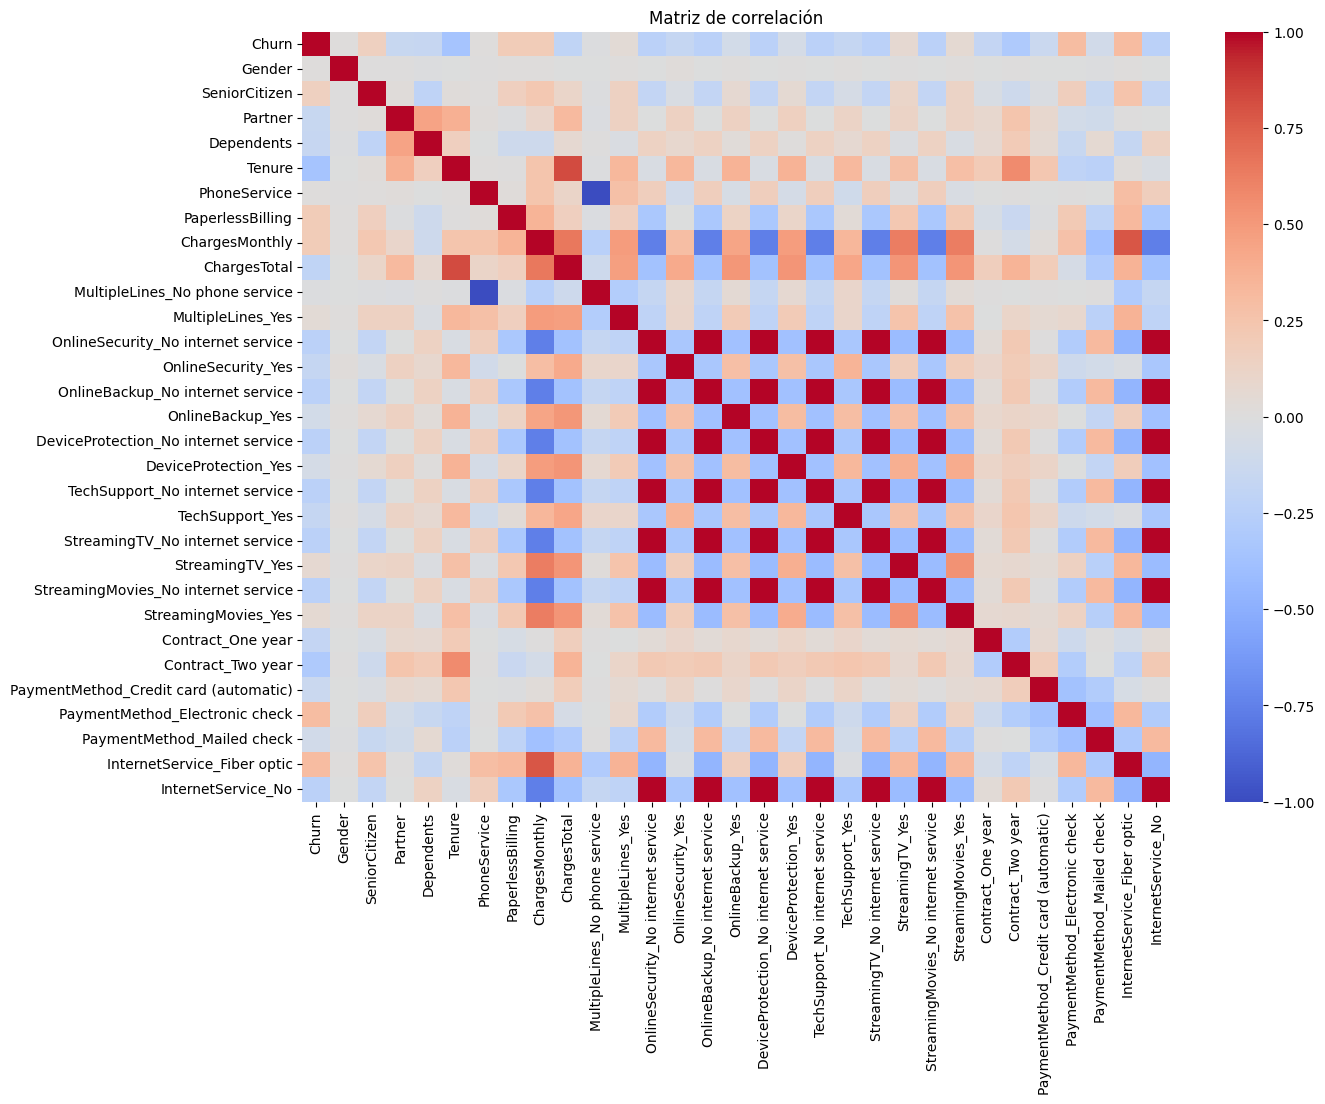

In [19]:
plt.figure(figsize=(14,10))
sns.heatmap(df_modelo.corr(), cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

La matriz de correlación permite identificar variables que presentan mayor relación con la cancelación (Churn), lo que puede ayudar a entender qué factores influyen más en el abandono de clientes.

### Análisis de la Matriz de Correlación (Churn)

**🔴 Correlaciones positivas con Churn (clientes que se van):**
- **InternetService_Fiber optic** → Clientes con fibra óptica se van más
- **PaperlessBilling** → Factura digital asociada a mayor churn
- **ChargesMonthly** → Mayor cargo mensual = más abandono
- **Contract_Month-to-month** → Sin contrato fijo = más fuga

**🔵 Correlaciones negativas con Churn (clientes que se quedan):**
- **Contract_Two year** → Contrato largo = mucha menor fuga
- **Contract_One year** → También reduce el churn
- **OnlineSecurity_Yes** → Tener seguridad online retiene clientes
- **TechSupport_Yes** → Soporte técnico reduce abandono
- **InternetService_No** → Sin internet = menor churn
- **Tenure** → Más antigüedad = más fidelidad

### Análisis de Multicolinealidad

Se analizó la matriz de correlación entre las variables predictoras para identificar posibles problemas de multicolinealidad.

Algunas variables numéricas, como ChargesMonthly y ChargesTotal, presentan cierta correlación debido a que el gasto total acumulado depende del gasto mensual y del tiempo de permanencia del cliente.

Sin embargo, el impacto de esta correlación es limitado en modelos basados en árboles como Random Forest, que son menos sensibles a la multicolinealidad.

En modelos lineales como la Regresión Logística, la multicolinealidad puede afectar la interpretación de los coeficientes, pero no necesariamente el poder predictivo del modelo.

## Análisis de variables vs churn
---

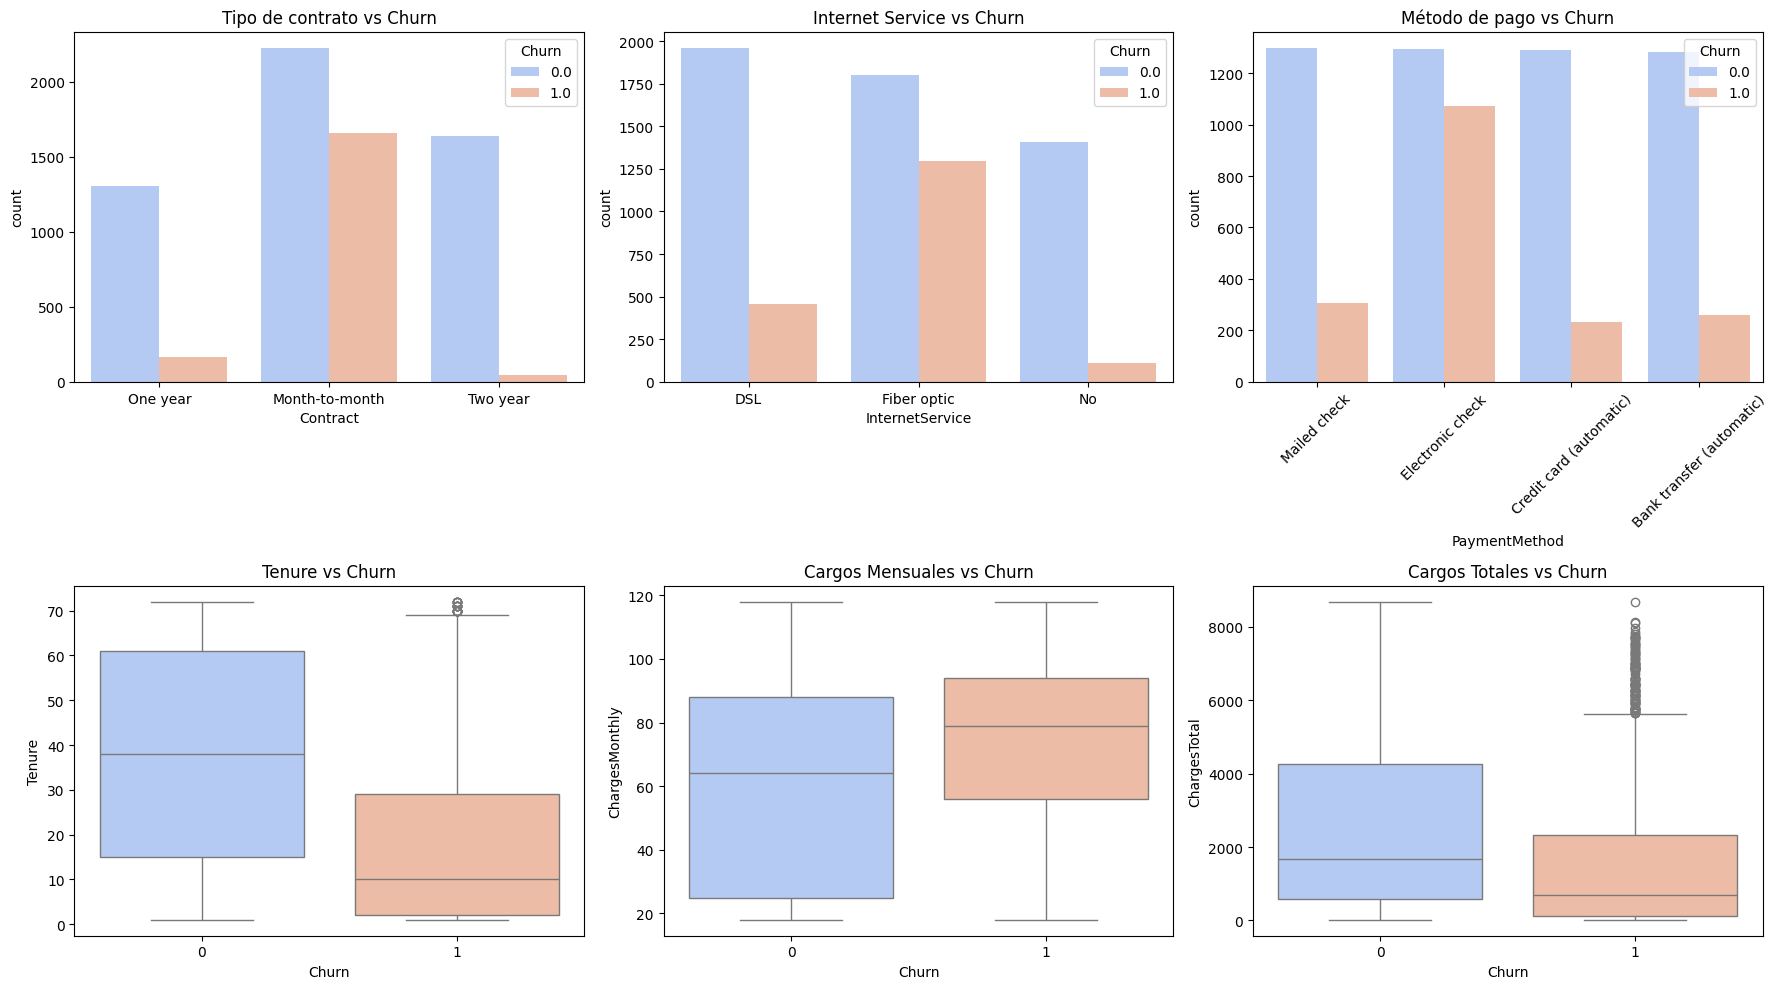

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Tipo de contrato vs Churn
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0,0], palette='coolwarm')
axes[0,0].set_title("Tipo de contrato vs Churn")

# Internet Service vs Churn
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title("Internet Service vs Churn")

# Método de pago vs Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[0,2], palette='coolwarm')
axes[0,2].set_title("Método de pago vs Churn")
axes[0,2].tick_params(axis='x', rotation=45)

# Tenure vs Churn
sns.boxplot(x='Churn', y='Tenure', data=df_modelo, ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title("Tenure vs Churn")

# Cargos mensuales vs Churn
sns.boxplot(x='Churn', y='ChargesMonthly', data=df_modelo, ax=axes[1,1], palette='coolwarm')
axes[1,1].set_title("Cargos Mensuales vs Churn")

# Charges Totales vs Churn
sns.boxplot(x='Churn', y='ChargesTotal', data=df_modelo, ax=axes[1,2], palette='coolwarm')
axes[1,2].set_title("Cargos Totales vs Churn")


plt.tight_layout()
plt.show()

### Hallazgos

- Clientes con menor tenure cancelan más.
- Clientes con mayor gasto mensual presentan mayor churn.
- El análisis muestra que los clientes que cancelan suelen presentar menores valores de gasto total. Esto puede deberse a que los clientes que permanecen más tiempo en la empresa acumulan un mayor gasto a lo largo del tiempo.
- Clientes con contratos mensuales cancelan más, igual que los que tienen internet de tipo fibra óptica y que hacen los pagos vía electrónica.

Estos patrones sugieren que la retención debería enfocarse en los primeros meses del cliente y en usuarios con contratos flexibles.

### Scatter: Tenure, Gasto Mensual y Churn

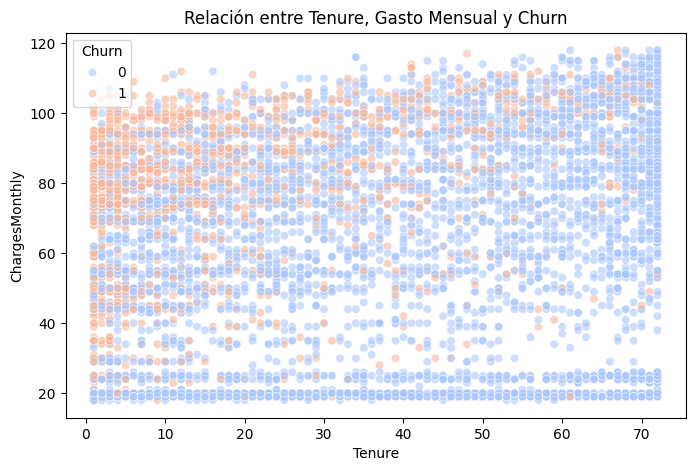

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Tenure', y='ChargesMonthly', hue='Churn', data=df_modelo, alpha=0.6, palette='coolwarm')
plt.title("Relación entre Tenure, Gasto Mensual y Churn")
plt.show()

Conclusión: Se observa que muchos clientes que cancelan se concentran en niveles bajos de tenure, incluso cuando el gasto mensual es alto. Esto refuerza la hipótesis de que los clientes nuevos presentan mayor riesgo de abandono.

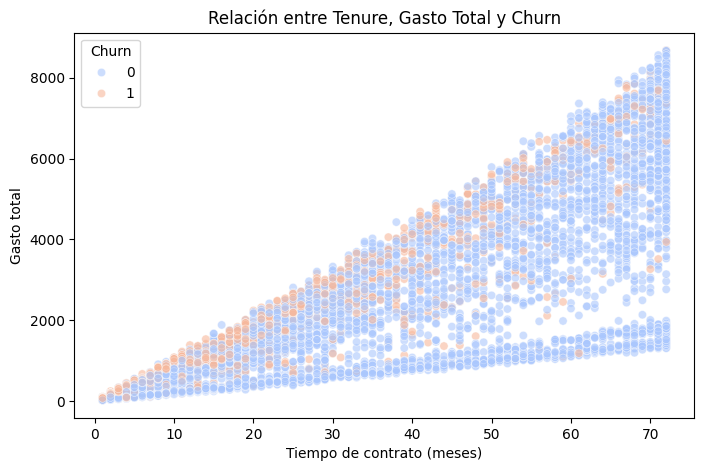

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_modelo,
    x='Tenure',
    y='ChargesTotal',
    hue='Churn',
    palette='coolwarm',
    alpha=0.6
)

plt.title('Relación entre Tenure, Gasto Total y Churn')
plt.xlabel('Tiempo de contrato (meses)')
plt.ylabel('Gasto total')
plt.show()

Conclusión: Se observa una correlación positiva clara: a mayor tiempo de contrato, mayor es el gasto total acumulado. Sin embargo, la dispersión aumenta significativamente a medida que avanza el tiempo (el "abanico" se abre). Esto sugiere que existen diferentes planes o niveles de consumo mensual (ARPU) entre los usuarios; algunos gastan mucho más que otros en el mismo periodo de tiempo. Además la gráfica nos arroja importantes insights:

### Patrones de Churn (Fuga de Clientes)
La variable Churn (donde 1 es naranja y 0 es azul) revela comportamientos críticos:

Concentración Inicial: Hay una densidad notable de puntos naranjas en los primeros meses (Tenure < 15) y con gastos totales bajos. Esto indica que un grupo importante de clientes abandona el servicio muy pronto.

Segmento de "Alto Valor en Riesgo": Se ven puntos naranjas dispersos en la parte superior del gráfico (gastos altos) incluso en contratos de mediana duración. Estos son clientes valiosos cuya fuga tiene un impacto económico mayor.

Lealtad a Largo Plazo: A medida que nos acercamos a los 70 meses, predomina el color azul. Los clientes que superan la barrera de los 20-30 meses tienden a ser más estables, aunque el riesgo nunca desaparece por completo.

### Anomalías en la Base
Llama la atención una línea de puntos azules muy marcada en la parte inferior del gráfico que crece muy lentamente. Estos parecen ser clientes con un consumo mínimo o planes básicos que, curiosamente, muestran una tasa de churn casi nula (casi no hay puntos naranjas en esa franja inferior).

## Verificar desbalance de clases
---

In [23]:
df_modelo['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


Conclusión: El análisis de la variable objetivo muestra que el 73.4% de los clientes permanecen activos, mientras que 26.6% cancelaron el servicio.
Esto indica un desbalance moderado entre las clases, lo cual puede influir en el desempeño del modelo, especialmente en métricas como recall o precision para la clase minoritaria (clientes que cancelan).

## Creación de modelos
---

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
# 1. Definimos X e y
X = df_modelo.drop(columns=['Churn'], axis = 1)
y = df_modelo['Churn']

# 2. Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=84)

In [26]:
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")


Dimensiones de X: (7032, 30)
Dimensiones de y: (7032,)


In [27]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Churn                                  7032 non-null   int64
 1   Gender                                 7032 non-null   int64
 2   SeniorCitizen                          7032 non-null   int64
 3   Partner                                7032 non-null   int64
 4   Dependents                             7032 non-null   int64
 5   Tenure                                 7032 non-null   int64
 6   PhoneService                           7032 non-null   int64
 7   PaperlessBilling                       7032 non-null   int64
 8   ChargesMonthly                         7032 non-null   int64
 9   ChargesTotal                           7032 non-null   int64
 10  MultipleLines_No phone service         7032 non-null   int64
 11  MultipleLines_Yes                  

## Normalización de valores (StandardScaler)
---

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
# Definimos las columnas que necesitan escala
columnas_escalar = ['Tenure', 'ChargesMonthly', 'ChargesTotal']

In [30]:
# Creamos el escalador
scaler = StandardScaler()

In [31]:
# Escalamos columnas_escalar en set de entrenamiento
X_train[columnas_escalar] = scaler.fit_transform(X_train[columnas_escalar])

# Escalamos columnas_escalar en set de prueba
X_test[columnas_escalar] = scaler.transform(X_test[columnas_escalar])

X_train.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,ChargesMonthly,ChargesTotal,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
165,1,0,1,1,1.407921,1,1,1.356877,1.958969,0,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0
3863,0,0,0,0,1.489417,1,1,1.356877,2.254223,0,1,0,0,0,1,0,0,0,1,0,1,0,1,1,0,0,0,0,1,0
2444,1,0,1,0,0.429978,1,0,0.527684,0.494172,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
5137,0,0,1,1,1.367174,1,1,0.660355,1.516308,0,1,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0
5761,0,0,1,1,1.448669,1,1,0.793026,1.700787,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0


## Continuación de creación de modelos para comparación
---

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [33]:
log_modelo = LogisticRegression(class_weight='balanced', random_state=84)

In [34]:
log_modelo.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=84)

In [35]:
rf_modelo = RandomForestClassifier(max_depth=5, class_weight='balanced', random_state=84)

In [36]:
rf_modelo.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=84)

In [37]:
# Hacemos las predicciones con los datos de prueba
y_pred_log = log_modelo.predict(X_test)

In [38]:
y_pred_rf = rf_modelo.predict(X_test)

Nota: El conjunto de datos presenta un desbalance moderado entre las clases. Para mitigar este efecto, se utilizó el parámetro class_weight='balanced' en los modelos, permitiendo que el algoritmo otorgue mayor peso a la clase minoritaria (clientes que cancelan). Esto ayuda a mejorar la capacidad del modelo para detectar casos de churn.

## Evaluación del modelo con métricas
---

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#### Modelo Logistic Regression

In [40]:
print("Accuracy LOG:", accuracy_score(y_test, y_pred_log))
print("Precision LOG:", precision_score(y_test, y_pred_log))
print("Recall LOG:", recall_score(y_test, y_pred_log))
print("F1 Score LOG:", f1_score(y_test, y_pred_log))

print("\nReporte Logistic Regression:")
print(classification_report(y_test, y_pred_log))

Accuracy LOG: 0.7545023696682465
Precision LOG: 0.5321100917431193
Recall LOG: 0.8083623693379791
F1 Score LOG: 0.6417704011065007

Reporte Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1536
           1       0.53      0.81      0.64       574

    accuracy                           0.75      2110
   macro avg       0.72      0.77      0.73      2110
weighted avg       0.81      0.75      0.77      2110



#### Modelo Random Forest

In [41]:
print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print("Precision RF:", precision_score(y_test, y_pred_rf))
print("Recall RF:", recall_score(y_test, y_pred_rf))
print("F1 RF:", f1_score(y_test, y_pred_rf))

print("\nReporte Random Forest:")
print(classification_report(y_test, y_pred_rf))

Accuracy RF: 0.7459715639810427
Precision RF: 0.5210643015521065
Recall RF: 0.818815331010453
F1 RF: 0.6368563685636857

Reporte Random Forest:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1536
           1       0.52      0.82      0.64       574

    accuracy                           0.75      2110
   macro avg       0.72      0.77      0.72      2110
weighted avg       0.81      0.75      0.76      2110



#### No parece haber overfitting, porque:

- Los modelos tienen rendimiento moderado

- No hay métricas extremadamente altas

- Random Forest además está limitado con max_depth=5. Eso evita que el modelo memorice el dataset.

#### Se podría decir que hay ligero underfitting, porque:

- Accuracy ≈ 75%

- Precision ≈ 52%

- F1 ≈ 0.63

Esto indica que el modelo no captura completamente todos los patrones del dataset. Los modelos aún podrían mejorar su capacidad para capturar patrones más complejos presentes en los datos.

Posible mejora: Probar modelos más avanzados.

### Resultados de comparación de modelos predictivos

In [42]:
resultados = {
    "Modelo": ["Logistic Regression", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
}

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.754502,0.532110,0.808362,0.641770
1,Random Forest,0.745972,0.521064,0.818815,0.636856


Considerando las métricas evaluadas, ambos modelos presentan un desempeño similar:

*Dos modelos con un Recall (Sensibilidad) muy alto, por encima del 80%.*

- Random Forest (Ganador en Detección): Tiene el Recall más alto (0.818). Esto significa que logra atrapar a casi el 82% de los clientes que planean irse.

- Logistic Regression (Ganador en Equilibrio): Aunque detecta un poquito menos (0.808), tiene una mejor Accuracy (0.75) y un mejor F1 Score (0.64). Es un modelo más "estable" y menos propenso a errores generales.

#### **Se selecciona la Random Forest como modelo principal (Champion) debido a que muestra una ligera ventaja en la capacidad de identificar clientes con riesgo de cancelación (mayor recall), lo cual puede ser más útil para estrategias de retención de clientes.**

## Matriz de confusión
---

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

### Para Logistic Regression

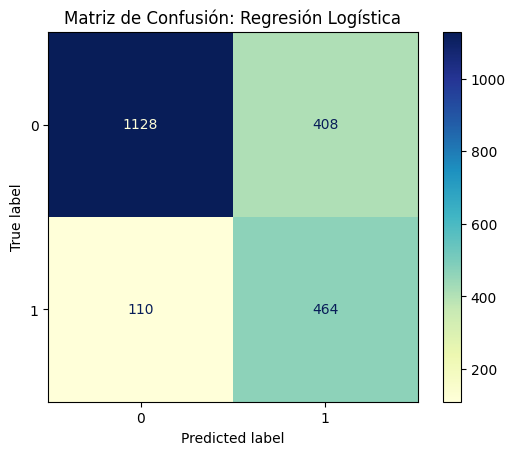

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap="YlGnBu")
plt.title("Matriz de Confusión: Regresión Logística")
plt.show()

### Para Logistic Random Forest

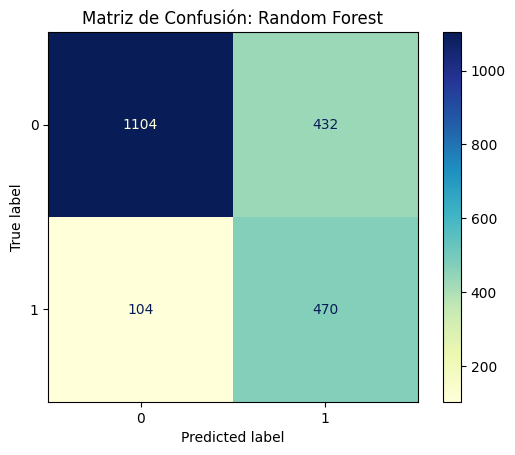

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="YlGnBu")
plt.title("Matriz de Confusión: Random Forest")
plt.show()

Continuamos observando un modelo similar de los modelos:

Los aciertos:
- Verdaderos Negativos (1128/1104): Tienen un comportamiento muy sólido identificando a los clientes que se quedan.
- Verdaderos Positivos (464/470): Han logrado detectar con éxito entre 464 y 470 clientes que realmente se iban a fugar.

Los Errores:
- Falsos Negativos (110/104): Este número Representa a clientes que el modelo dijo que se quedarían, pero que en realidad se fueron. Para la empresa, esto es "dinero que se escapa" sin aviso.
- Falsos Positivos (408/432): Los modelos predijeron que se irían, pero se quedaron. Aquí el riesgo es molestar a un cliente fiel con promociones innecesarias o gastar presupuesto de marketing en quien no lo necesitaba. Genera falsas alarmas.

### Comparación ROC de ambos modelos

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

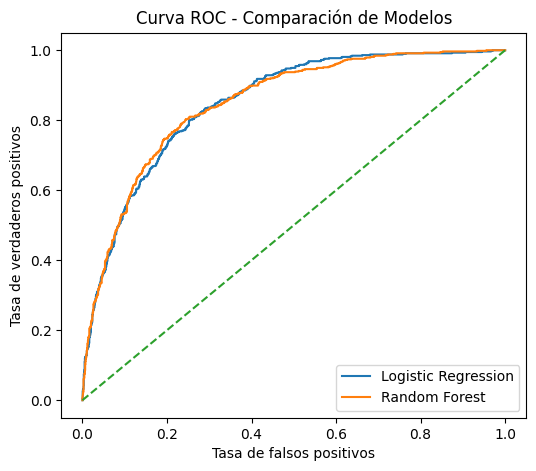

In [47]:
# Probabilidades
y_prob_log = log_modelo.predict_proba(X_test)[:,1]
y_prob_rf = rf_modelo.predict_proba(X_test)[:,1]

# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Comparación de Modelos")
plt.legend()

plt.show()

In [48]:
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("AUC Logistic Regression:", auc_log)
print("AUC Random Forest:", auc_rf)

AUC Logistic Regression: 0.8494647620862369
AUC Random Forest: 0.8493626823824042


Conclusión: ambos modelos tienen un desempeño muy similar, ya que en la gráfica-ROC las curvas azul y naranja están prácticamente superpuestas durante la mayor parte del recorrido. Con un buen poder predictivo. Y los datos tienen una estructura mayormente lineal ya que Random Forest no muestra una ventaja evidente en la gráfica.

En cuanto al AUC:

AUC ≈ 0.8 → buen modelo


## Importancia de variables
---

### Con Random Forest

In [49]:
importancias = pd.Series(
    rf_modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias.head(10))

Tenure                                  0.174112
Contract_Two year                       0.154154
ChargesTotal                            0.110365
InternetService_Fiber optic             0.090074
PaymentMethod_Electronic check          0.058537
TechSupport_Yes                         0.048066
DeviceProtection_No internet service    0.042519
Contract_One year                       0.042258
ChargesMonthly                          0.037764
OnlineSecurity_Yes                      0.033385
dtype: float64


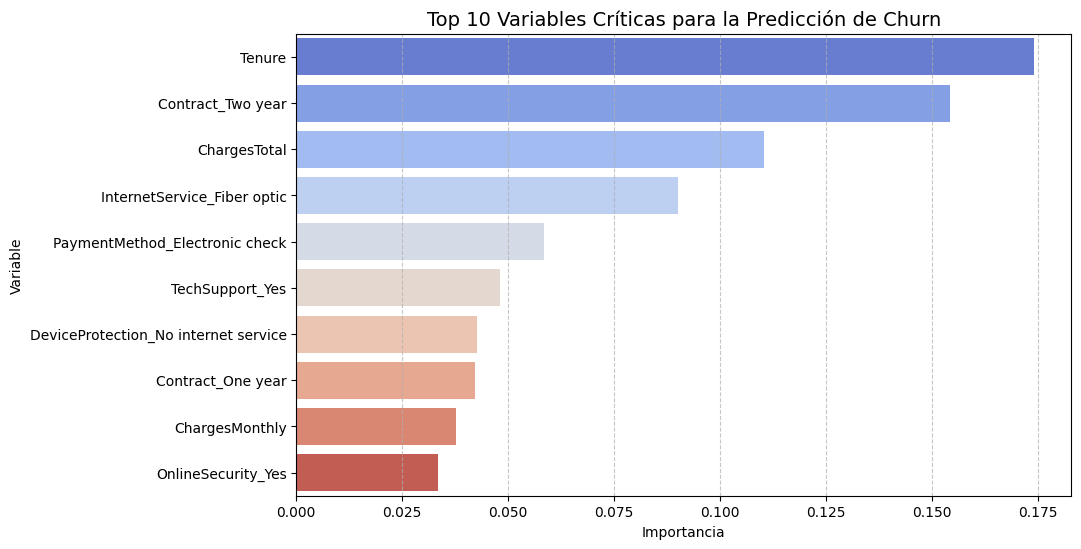

In [50]:
df_importancia = importancias.head(10).reset_index()
df_importancia.columns = ['Variable', 'Importancia']

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='coolwarm')
plt.title("Top 10 Variables Críticas para la Predicción de Churn", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Con Logistic Regression

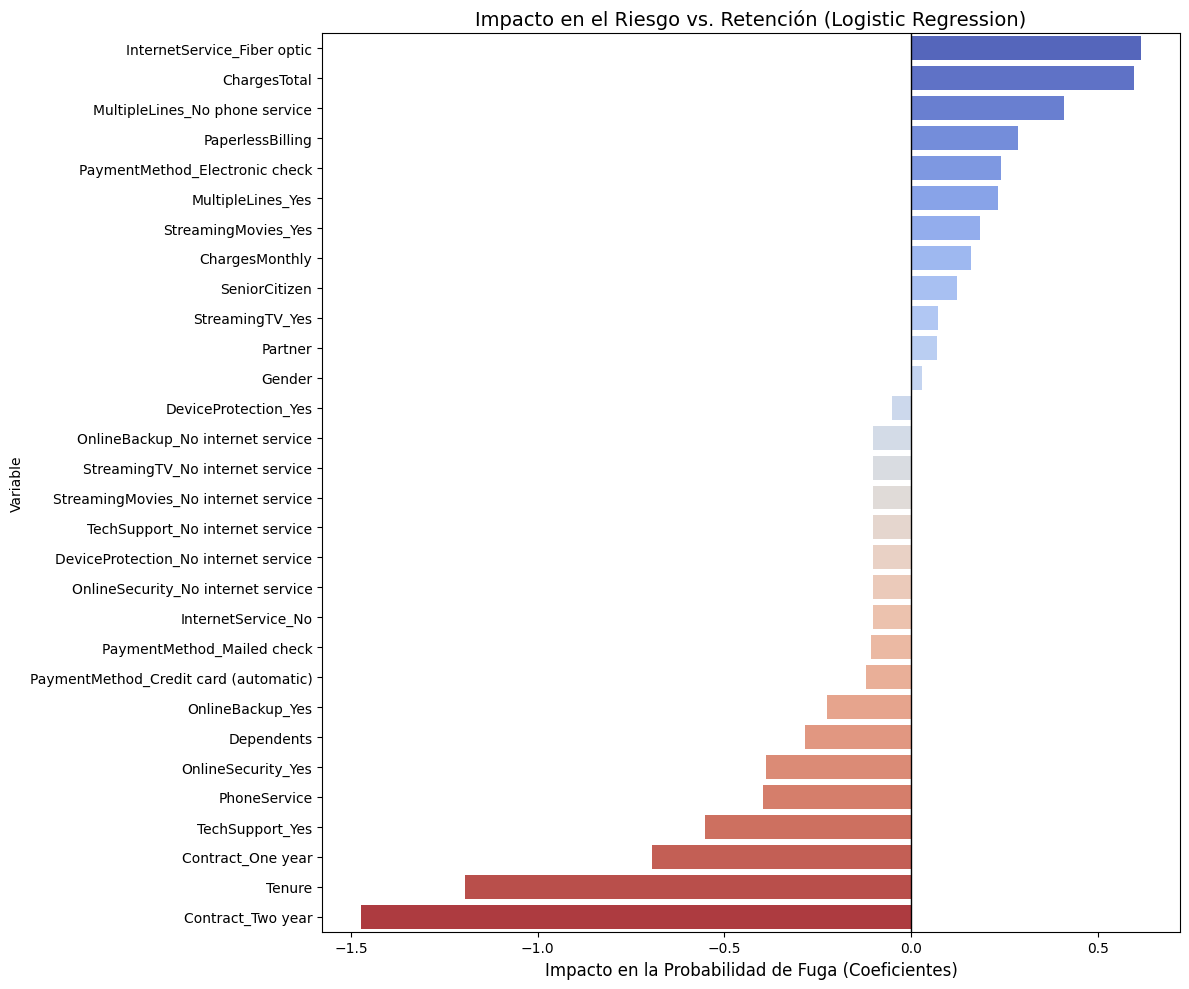

🔴 TOP 5 ALERTAS DE RIESGO (Aumentan el Churn):
                          Variable  Coeficiente
28     InternetService_Fiber optic     0.616301
8                     ChargesTotal     0.597989
9   MultipleLines_No phone service     0.410083
6                 PaperlessBilling     0.286920
26  PaymentMethod_Electronic check     0.240452

🔵 TOP 5 FORTALEZAS DE RETENCIÓN (Evitan el Churn):
             Variable  Coeficiente
5        PhoneService    -0.397703
18    TechSupport_Yes    -0.551768
23  Contract_One year    -0.694169
4              Tenure    -1.195498
24  Contract_Two year    -1.473716


In [51]:
importancia_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_modelo.coef_[0]
})

# Ordenamos de mayor riesgo a mayor lealtad
importancia_log = importancia_log.sort_values(by='Coeficiente', ascending=False)

# Visualización con colores estratégicos (Rojo para riesgo, Verde para lealtad)
plt.figure(figsize=(12, 10))
sns.barplot(x='Coeficiente', y='Variable', data=importancia_log, palette='coolwarm')

plt.title('Impacto en el Riesgo vs. Retención (Logistic Regression)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Impacto en la Probabilidad de Fuga (Coeficientes)', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen Ejecutivo
print("🔴 TOP 5 ALERTAS DE RIESGO (Aumentan el Churn):")
print(importancia_log.head(5))

print("\n🔵 TOP 5 FORTALEZAS DE RETENCIÓN (Evitan el Churn):")
print(importancia_log.tail(5))

## Automatización del flujo con Pipeline
---

En proyectos de Machine Learning es una buena práctica utilizar Pipelines para automatizar el flujo de preprocesamiento y modelado.

Un Pipeline permite encadenar pasos como normalización de datos y entrenamiento del modelo en una sola estructura, evitando errores de data y facilitando la reutilización del modelo en nuevos datos.

In [52]:
from sklearn.pipeline import Pipeline

### Para Logistic Regression

In [53]:
pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(class_weight='balanced', random_state=84))
])

pipeline_log.fit(X_train, y_train)

y_pred_pipe_log = pipeline_log.predict(X_test)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred_pipe_log))
print("Precision:", precision_score(y_test, y_pred_pipe_log))
print("Recall:", recall_score(y_test, y_pred_pipe_log))
print("F1:", f1_score(y_test, y_pred_pipe_log))

Accuracy: 0.7535545023696683
Precision: 0.5309633027522935
Recall: 0.8066202090592335
F1: 0.640387275242047


### Para Random Forest

In [55]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=84
    ))
])

pipeline_rf.fit(X_train, y_train)

y_pred_pipe_rf = pipeline_rf.predict(X_test)

In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred_pipe_rf))
print("Precision:", precision_score(y_test, y_pred_pipe_rf))
print("Recall:", recall_score(y_test, y_pred_pipe_rf))
print("F1:", f1_score(y_test, y_pred_pipe_rf))

Accuracy: 0.7459715639810427
Precision: 0.5210643015521065
Recall: 0.818815331010453
F1: 0.6368563685636857


Los resultados obtenidos son muy similares a los
modelos entrenados previamente de forma manual, lo cual confirma que el pipeline
reproduce correctamente el flujo de procesamiento y modelado.

## 💡Conclusiones y Recomendaciones
---

### Resultados del modelo

Los modelos de Regresión Logística y Random Forest alcanzaron una exactitud cercana al 75%, con un recall superior al 80%, lo que indica una buena capacidad para identificar clientes con riesgo de cancelación.

Entre ambos modelos, Random Forest mostró una ligera ventaja en la detección de churn, lo cual puede ser especialmente útil para estrategias de retención, ya que permite identificar más clientes potencialmente en riesgo.

### Variables que más influyen en la cancelación

El análisis de importancia de variables mostró que los factores más asociados con la cancelación son:

- Tipo de contrato (Contract)

- Tiempo de permanencia del cliente (Tenure)

- Gasto mensual (ChargesMonthly)

- Tipo de servicio de internet (InternetService_Fiber)

### Principales patrones identificados

A partir del análisis exploratorio y del modelo predictivo se identificaron los siguientes patrones:

- Los clientes con contratos mensuales presentan mayor probabilidad de cancelar el servicio.

- Los clientes con menor tiempo de permanencia (tenure bajo) muestran mayor tendencia al abandono.

- Los clientes con servicio de fibra óptica presentan una tasa de cancelación más elevada, lo que podría estar asociado a expectativas de servicio, precio o competencia.

- Los clientes con mayor gasto mensual también presentan mayor riesgo de churn, lo que podría indicar sensibilidad al precio.

### Recomendaciones estratégicas para Telecom X

Con base en los resultados obtenidos, se sugieren las siguientes acciones para reducir la cancelación de clientes:

1. Incentivar contratos de largo plazo

Promover planes con contratos anuales o de dos años mediante descuentos o beneficios adicionales, con el objetivo de aumentar la retención de clientes.

2. Implementar estrategias de retención temprana

Los primeros meses del cliente son críticos. Se recomienda implementar programas de fidelización o seguimiento durante los primeros meses de servicio para mejorar la experiencia del cliente.

3. Revisar la propuesta de valor de los planes de fibra óptica

Dado que los clientes con fibra presentan mayor tasa de cancelación, sería recomendable analizar factores como precios, calidad del servicio o soporte técnico para identificar posibles causas del abandono.

4. Diseñar ofertas personalizadas para clientes de alto gasto

Los clientes con mayor gasto mensual podrían beneficiarse de programas de lealtad, descuentos o servicios adicionales que aumenten su percepción de valor.

## ✨ Bonus: Simulación con cliente particular para predecir posibilidades de Churn

Para ilustrar el uso práctico del modelo, se creó un ejemplo de cliente con características específicas. El modelo estima la probabilidad de que este cliente cancele el servicio. Este tipo de predicción permite identificar clientes con alto riesgo de abandono y aplicar estrategias de retención antes de que se produzca la cancelación.

#### Cliente:

In [57]:
cliente = {
    'Gender': 1,
    'SeniorCitizen': 0,
    'Partner': 1,
    'Dependents': 0,
    'Tenure': 5,
    'PhoneService': 1,
    'PaperlessBilling': 1,
    'ChargesMonthly': 85,
    'ChargesTotal': 425,

    'MultipleLines_No phone service': 0,
    'MultipleLines_Yes': 1,

    'OnlineSecurity_No internet service': 0,
    'OnlineSecurity_Yes': 0,

    'OnlineBackup_No internet service': 0,
    'OnlineBackup_Yes': 1,

    'DeviceProtection_No internet service': 0,
    'DeviceProtection_Yes': 1,

    'TechSupport_No internet service': 0,
    'TechSupport_Yes': 0,

    'StreamingTV_No internet service': 0,
    'StreamingTV_Yes': 1,

    'StreamingMovies_No internet service': 0,
    'StreamingMovies_Yes': 1,

    'Contract_One year': 0,
    'Contract_Two year': 0,

    'PaymentMethod_Credit card (automatic)': 0,
    'PaymentMethod_Electronic check': 1,
    'PaymentMethod_Mailed check': 0,

    'InternetService_Fiber optic': 1,
    'InternetService_No': 0
}

In [58]:
cliente_df = pd.DataFrame([cliente])

#### Predicción:

In [59]:
pred = pipeline_rf.predict(cliente_df)

prob = pipeline_rf.predict_proba(cliente_df)[0][1]

if pred[0] == 1:
    print("⚠️ Cliente con alto riesgo de cancelación")
else:
    print("✅ Cliente con bajo riesgo de cancelación")
print(f"Probabilidad de churn: {prob:.2%}")


⚠️ Cliente con alto riesgo de cancelación
Probabilidad de churn: 56.52%
